## Evaluación de Modelos

# 1. Predicción de `gasto_mensual`
En esta sección evaluaremos el rendimiento de los modelos entrenados para predecir el gasto mensual de los clientes. Utilizaremos el Error Absoluto Medio (MAE), el RMSE , y el R².

In [22]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from pathlib import Path
import sys

# configura el path al directorio src
project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from model_evaluation import evaluar_regresor, comparar_modelos_regresion

# define rutas relativas al proyecto
base_dir = project_root if "project_root" in globals() else Path.cwd().resolve()
ruta_modelos = base_dir / "models"
ruta_datos = base_dir / "data" / "processed"

In [23]:
# carga los conjuntos de prueba
X_test = joblib.load(ruta_datos / "X_test.joblib")
y_test = joblib.load(ruta_datos / "y_test.joblib")

# carga los modelos entrenados
pipeline_modelo_lr = joblib.load(ruta_modelos / "pipeline_modelo_lr.joblib")
pipeline_modelo_dtr = joblib.load(ruta_modelos / "pipeline_modelo_dtr.joblib")

# prepara el diccionario para la evaluación 
modelos_entrenados = {
    "Regresión Lineal": pipeline_modelo_lr,
    "Árbol de Decisión": pipeline_modelo_dtr
}

print(f"Datos cargados. X_test shape: {X_test.shape}. Modelos listos para evaluar.")

Datos cargados. X_test shape: (5700, 10). Modelos listos para evaluar.


## Comparación de Métricas de Rendimiento
Utilizamos nuestra función personalizada para evaluar los modelos simultáneamente utilizando el Error Absoluto Medio (MAE), la Raíz del Error Cuadrático Medio (RMSE) y el Coeficiente de Determinación (R²).

In [24]:
# Evaluamos y ordenamos priorizando un menor RMSE
df_comparacion = comparar_modelos_regresion(modelos_entrenados, X_test, y_test, sort_by="RMSE")
display(df_comparacion)

,MAE,RMSE,R2
Modelo,,,
Regresión Lineal,118594.817257,148799.190098,0.000638
Árbol de Decisión,119652.896798,150134.445772,-0.017378


## Visualización Comparativa
Una representación gráfica nos permite dimensionar rápidamente las diferencias en las magnitudes de los errores y la varianza explicada.

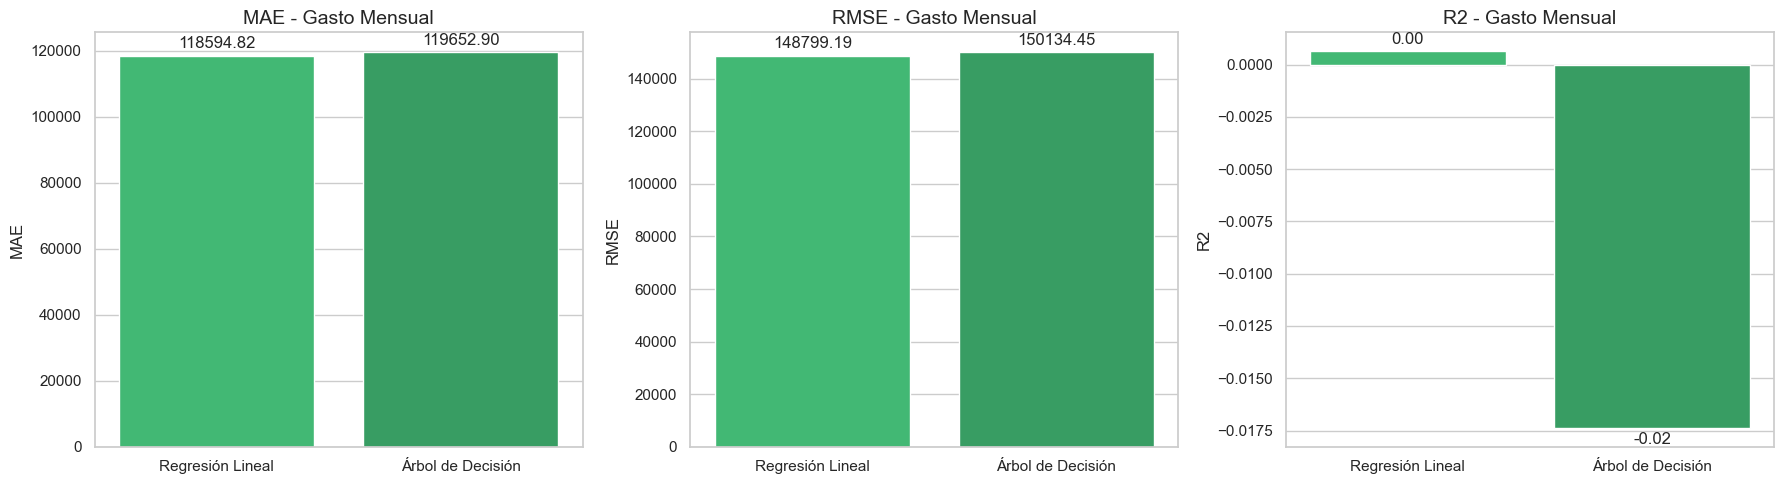

In [27]:
# visualización de las métricas para gasto_mensual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metricas = ['MAE', 'RMSE', 'R2']
colores = ['#2ECC71', '#27AE60']

for i, metrica in enumerate(metricas):
    sns.barplot(
        x=df_comparacion.index,
        y=df_comparacion[metrica],
        hue=df_comparacion.index,
        ax=axes[i],
        palette=colores,
        legend=False,
    )
    axes[i].set_title(f'{metrica} - Gasto Mensual', fontsize=14)
    axes[i].set_ylabel(metrica)
    axes[i].set_xlabel('')
    
    # Añadir valores sobre las barras
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### Interpretación de Resultados: `gasto_mensual`

Al analizar rigurosamente las métricas obtenidas para la predicción del gasto mensual, podemos establecer las siguientes conclusiones tanto a nivel técnico como de negocio:

1. **Precisión Financiera y Magnitud de Error (MAE y RMSE):**
   - El modelo de **Regresión Lineal** se posiciona como el de mejor desempeño, presentando un Error Absoluto Medio (MAE) de **118,594.82**. Nuestras predicciones se desvían de la realidad por casi 118,600 unidades monetarias.
   - Al observar el **RMSE (148,799.19)**, notamos que es considerablemente mayor que el MAE. El modelo está cometiendo errores de gran magnitud.

2. **Capacidad Explicativa (R²):**
   - El modelo ganador logró un **R² de apenas 0.001**. Esto se traduce en que el modelo logra explicar únicamente el **0.1%** de la variabilidad en los gastos mensuales de los clientes. 
   - Una capacidad explicativa tan baja evidencia que las características o variables independientes que estamos introduciendo al modelo actualmente no permiten predecir el comportamiento de gasto.

3. **Comparativa de Modelos (Regresión Lineal vs. Árbol de Decisión):**
   - La Regresión Lineal superó al Árbol de Decisión, pero lo hizo por un margen muy estrecho. Logró reducir el RMSE en **1,335.26 unidades** (lo que representa una mejora marginal de apenas el **0.9%**), disminuyó el MAE en **1,058.08 unidades** y mejoró el R² en **0.018**.
   - **Conclusión General:** Aunque matemáticamente la Regresión Lineal es el "mejor modelo", en un entorno de producción o de negocio ambos algoritmos demuestran ser insuficientes en su estado actual. El hecho de que ambos modelos fallen de forma similar confirma que la limitante principal no es el algoritmo elegido, sino la ausencia de poder predictivo en las variables actuales.